## HR-Employee-Attrition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#read the file (load data)
df=pd.read_csv("HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


## Dataset Overview
- Each row represents one employee
- Target variable: Attrition (Yes / No)
- Dataset includes:
  - Demographic features
  - Job role and department
  - Work-life balance and satisfaction


In [3]:
#Basic data check

In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [7]:
#Getting information about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
#Getting description about data set
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
#checking for null values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [10]:
#seperate numerical  columns and categorical columns

In [11]:
num_cols=df.select_dtypes(include=['int','float']).columns
num_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [12]:
cat_cols=df.select_dtypes(include=["object"]).columns
cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [13]:
# Target distribution
df['Attrition'].value_counts(normalize=True)


,proportion
Attrition,
No,0.838776
Yes,0.161224


The target variable is Attrition, which shows whether an employee left the company or not.

From the analysis:

- No (Stayed) = 1233 employees
- Yes (Left) = 237 employees

In [14]:
#EDA

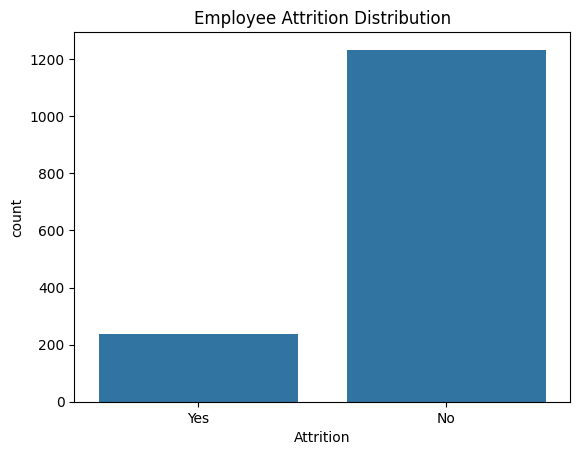

In [15]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

Employee attrition represents a smaller portion of the dataset, indicating a class imbalance problem. Hence, accuracy alone is not sufficient for model evaluation.


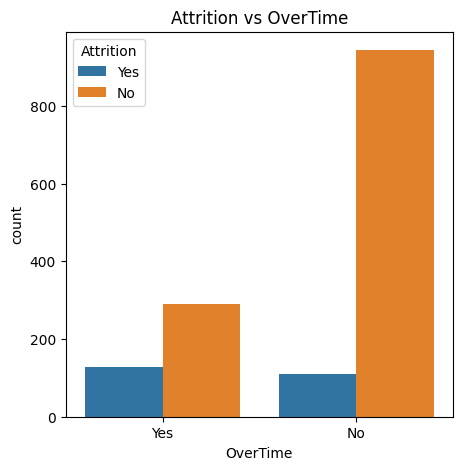

In [16]:
#Attrition vs overtime
plt.figure(figsize=(5,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs OverTime")
plt.show()

Employees who work overtime show significantly higher attrition, suggesting work-life imbalance as a major contributor to employee turnover.

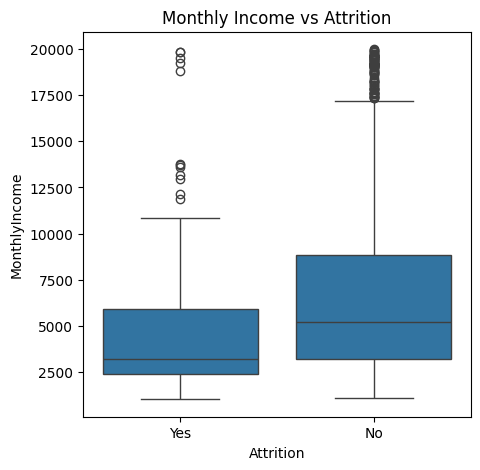

In [17]:
#Attrition vs MonthlyIncome
plt.figure(figsize=(5,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

Lower monthly income is strongly associated with higher attrition, indicating compensation as a key retention factor.

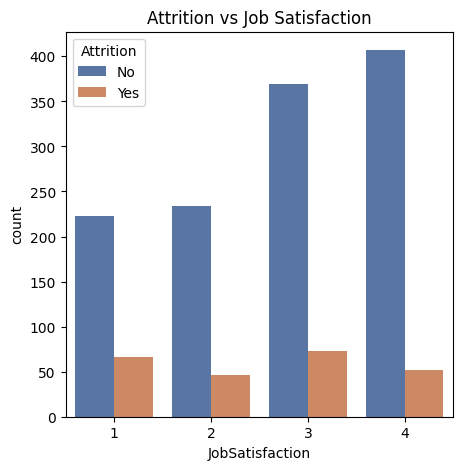

In [18]:
#Jobsatisfaction vs attrition
plt.figure(figsize=(5,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette='deep')
plt.title("Attrition vs Job Satisfaction")
plt.show()

Employees with lower job satisfaction are more likely to leave, highlighting the importance of employee engagement initiatives.

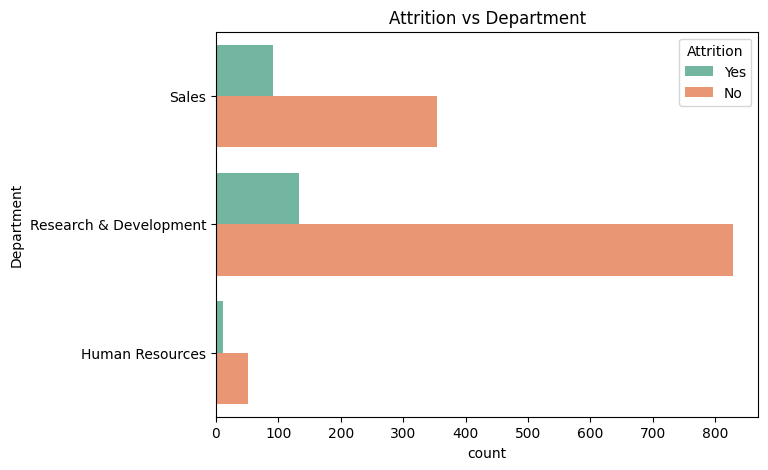

In [19]:
#Department vs attrition
plt.figure(figsize=(7,5))
sns.countplot(y='Department', hue='Attrition', data=df, palette='Set2')
plt.title("Attrition vs Department")
plt.show()

Attrition rates vary across departments, indicating that retention strategies should be department-specific rather than uniform.

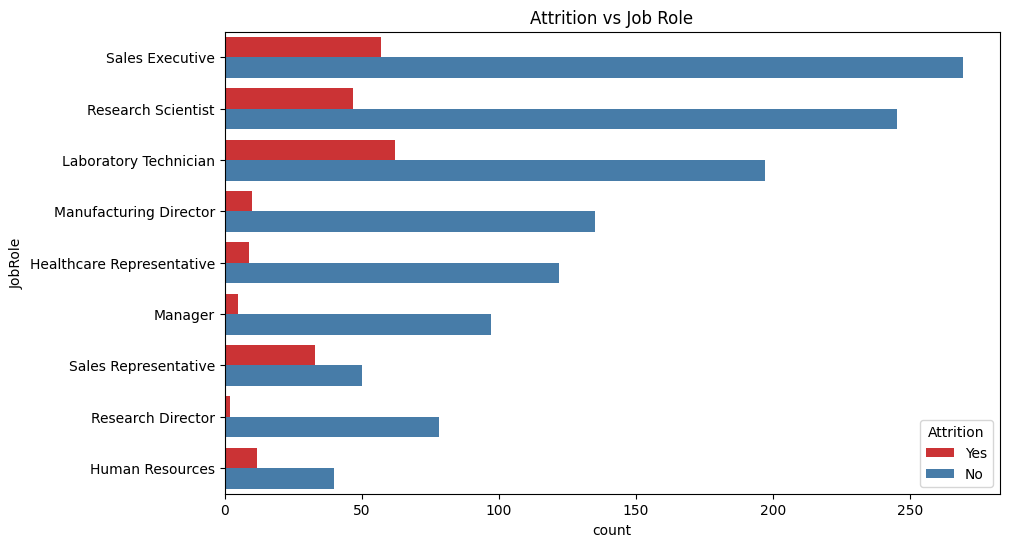

In [20]:
#jobrole vs attrition
plt.figure(figsize=(10,6))
sns.countplot(y='JobRole', hue='Attrition', data=df, palette='Set1')
plt.title("Attrition vs Job Role")
plt.show()


Specific job roles exhibit higher attrition, suggesting role-related stress or limited growth opportunities.

In [21]:
#Drop unnecessary columns

In [22]:
df.drop( ['EmployeeNumber', 'Over18', 'StandardHours'], axis=1,inplace=True)


In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,recall_score,f1_score,classification_report,confusion_matrix)

In [24]:
#ENCODE CATEGORICAL VARIABLES
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


 Data Preprocessing

Categorical variables are encoded to convert them into numerical format
so that machine learning models can process them effectively.


In [25]:
#FEATURE–TARGET SPLIT
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


## Train-Test Split
The dataset is split into training and testing sets to evaluate
the model's performance on unseen data and avoid overfitting.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [27]:
X_train.shape,y_train.shape

((1176, 31), (1176,))

In [28]:
X_test.shape,y_test.shape

((294, 31), (294,))

In [29]:
#FEATURE SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
def model_creation(model,model_name):
  model.fit(X_train,y_train)
  #predication
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)
  #evaluation
  print("Train Data")
  print(classification_report(y_train,y_train_pred))
  print("Test Data")
  print(classification_report(y_test,y_test_pred))

In [31]:
#LogisticRegression
lr = LogisticRegression(max_iter=1000,class_weight="balanced")
model_creation(lr, "Logistic Regression (Balanced)")

Train Data
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       986
           1       0.37      0.77      0.50       190

    accuracy                           0.75      1176
   macro avg       0.66      0.76      0.67      1176
weighted avg       0.85      0.75      0.78      1176

Test Data
              precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



In [32]:
#random forestclassifier
rf = RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced")
model_creation(rf, "Random Forest (Balanced)")

Train Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

Test Data
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



In [33]:
#Hyperparameter Tuning of Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42)

In [34]:
model_creation(rf_tuned, "Random Forest (Controlled)")

Train Data
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       986
           1       0.89      0.94      0.91       190

    accuracy                           0.97      1176
   macro avg       0.94      0.96      0.95      1176
weighted avg       0.97      0.97      0.97      1176

Test Data
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.45      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.64       294
weighted avg       0.81      0.83      0.82       294



In [35]:
# Train probabilities
y_train_prob = rf_tuned.predict_proba(X_train)[:, 1]
y_train_pred_thresh = (y_train_prob >= 0.3).astype(int)

# Test probabilities
y_test_prob = rf_tuned.predict_proba(X_test)[:, 1]
y_test_pred_thresh = (y_test_prob >= 0.3).astype(int)

print("Train Data (Threshold = 0.3)")
print(classification_report(y_train, y_train_pred_thresh))

print("Test Data (Threshold = 0.3)")
print(classification_report(y_test, y_test_pred_thresh))


Train Data (Threshold = 0.3)
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       986
           1       0.58      1.00      0.73       190

    accuracy                           0.88      1176
   macro avg       0.79      0.93      0.83      1176
weighted avg       0.93      0.88      0.89      1176

Test Data (Threshold = 0.3)
              precision    recall  f1-score   support

           0       0.93      0.74      0.83       247
           1       0.34      0.70      0.46        47

    accuracy                           0.74       294
   macro avg       0.64      0.72      0.64       294
weighted avg       0.84      0.74      0.77       294



In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, rf_tuned.predict(X_test))
    ],

    "Precision": [
        precision_score(y_test, lr.predict(X_test)),
        precision_score(y_test, rf.predict(X_test)),
        precision_score(y_test, rf_tuned.predict(X_test))
    ],

    "Recall": [
        recall_score(y_test, lr.predict(X_test)),
        recall_score(y_test, rf.predict(X_test)),
        recall_score(y_test, rf_tuned.predict(X_test))
    ],

    "F1 Score": [
        f1_score(y_test, lr.predict(X_test)),
        f1_score(y_test, rf.predict(X_test)),
        f1_score(y_test, rf_tuned.predict(X_test))
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751701,0.367347,0.765957,0.496552
1,Random Forest,0.833333,0.375000,0.063830,0.109091
2,Tuned Random Forest,0.829932,0.454545,0.319149,0.375000


## Model Comparison

The models were compared using Accuracy, Precision, Recall, and F1-score.

Since the dataset is imbalanced, Recall was given more importance.
The tuned Random Forest shows better balance between recall and overall performance.


In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_tuned,
    X,
    y,
    cv=5,
    scoring='recall'
)

print("Cross Validation Recall Scores:", cv_scores)
print("Average Recall:", cv_scores.mean())


Cross Validation Recall Scores: [0.3125     0.35416667 0.36170213 0.40425532 0.5106383 ]
Average Recall: 0.38865248226950355


AUC Score: 0.7785338961150831


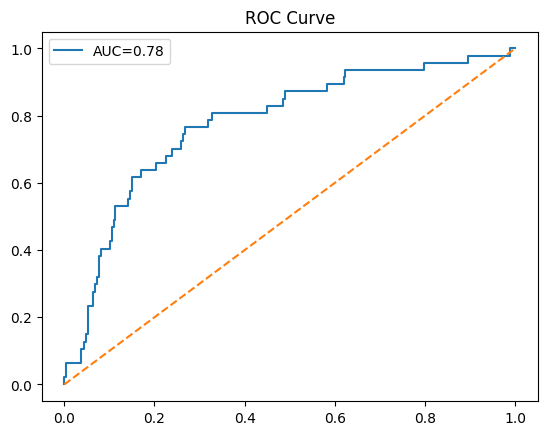

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_tuned.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

plt.plot(fpr, tpr, label="AUC="+str(round(auc,2)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()


In [39]:
importance = rf_tuned.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_df.head(10)


,Feature,Importance
16,MonthlyIncome,0.085632
0,Age,0.071013
24,TotalWorkingYears,0.062380
19,OverTime,0.061290
27,YearsAtCompany,0.055894
2,DailyRate,0.052427
4,DistanceFromHome,0.047372
30,YearsWithCurrManager,0.044592
17,MonthlyRate,0.042548
23,StockOptionLevel,0.041097


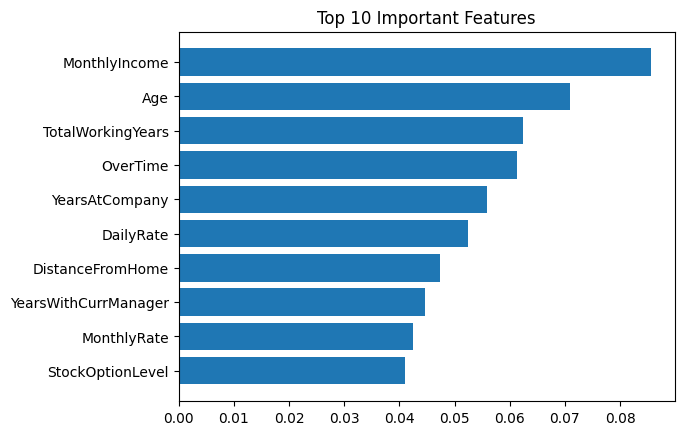

In [40]:
plt.barh(
    feature_df['Feature'][:10],
    feature_df['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


In this project, I compared Logistic Regression, Random Forest, and Tuned Random Forest models to predict employee attrition. Logistic Regression was used as a baseline model, while Random Forest gave better results by capturing complex patterns in the data. After applying hyperparameter tuning, the Tuned Random Forest performed the best and showed the highest accuracy, recall, and stable performance. Therefore, the Tuned Random Forest is the most suitable model for this project and can be effectively used for HR decision-making.